## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

# Práctica # 15. Machine Learning (Aprendizaje No-Supervisado).

### El aprendizaje no supervisado es un tipo de aprendizaje automático (machine learning) en el que el algoritmo aprende a partir de datos que no están etiquetados, es decir, no se le dice al algoritmo qué resultado esperar.

### ¿Qué es K-means?
K-means es un algoritmo de clustering (agrupamiento).  
Sirve para agrupar datos similares en grupos llamados "clusters".

### ¿Para qué se usa?
Imagina que tienes muchos puntos de datos (como personas con diferentes alturas y pesos), y quieres agruparlos por similitud sin saber previamente a qué grupo pertenecen.  
K-means te ayuda a descubrir esos grupos.

### ¿Cómo funciona?

1. Elige cuántos grupos (k) quieres formar.  
   Por eso se llama K-means: "k" es el número de grupos.

2. Coloca aleatoriamente "k" puntos centrales (llamados centroides).

3. Asigna cada punto al centro más cercano.  
   Así se forman los primeros grupos.

4. Recalcula el centro de cada grupo.

5. Repite los pasos 3 y 4 hasta que los grupos no cambien mucho.

# IMPLEMENTACIÓN DE K-MEANS

En esta práctica implementaremos K-Means para realizar tres clusters de notas escolares.  
El DataSet utilizado es un DataSet diseñado con propósitos educativos.


### Paso 1: Importar las librerías necesarias

In [1]:
### Paso 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración visual
plt.style.use('ggplot')



### Paso 2: obtener los datos

In [2]:
### Paso 2: Cargar el dataset de notas escolares
file_path = '../EjemploEstudiantes.csv'

try:
    # Reutilizamos la configuración correcta de la práctica anterior
    df = pd.read_csv(file_path, sep=';', decimal=',', index_col=0)
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo. Verifica la ruta.")

display(df.head())

Dataset cargado exitosamente.


,Matematicas,Ciencias,Espanol,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3


### Paso 3: Preprocesamiento de datos y ejecución del K-means

In [3]:
### Paso 3: Preprocesamiento y ejecución del algoritmo K-Means

# 3.1 Escalar los datos (importante para que todas las materias pesen igual)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 3.2 Configurar y entrenar el modelo K-Means para k=3
# Usamos random_state=42 para que los resultados sean reproducibles (equivalente a set.seed en R)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(df_scaled)

# 3.3 Añadir la columna de clusters al DataFrame original para su análisis
df['Cluster_KMeans'] = clusters_kmeans

print("Agrupamiento K-Means finalizado.")
display(df[['Cluster_KMeans']].head(8)) # Mostramos a qué cluster fue asignado cada uno

Agrupamiento K-Means finalizado.


,Cluster_KMeans
Lucia,1
Pedro,2
Ines,2
Luis,0
Andres,1
Ana,2
Carlos,1
Jose,2


### Paso 4. Guardando la Tabla de Datos con el Cluster al que Pertenece Cada Individuo.
Ya que hemos asignado cada estudiante a un cluster, uniremos esta información al conjunto de datos original y lo exportaremos a un nuevo archivo CSV para futuros análisis.

In [4]:
# 4.1 Mostrar los datos originales junto con su cluster asignado (equivalente a cbind)
print("--- Datos con el Cluster Asignado ---")
display(df)

# 4.2 Guardar el nuevo dataset en un archivo CSV (equivalente a write.csv)
# Guardaremos el archivo en la misma carpeta donde estamos trabajando
ruta_salida = 'NDatos.csv'
df.to_csv(ruta_salida)

print(f"Los datos han sido guardados exitosamente en: {ruta_salida}")

--- Datos con el Cluster Asignado ---


,Matematicas,Ciencias,Espanol,Historia,EdFisica,Cluster_KMeans
Lucia,7.0,6.5,9.2,8.6,8.0,1
Pedro,7.5,9.4,7.3,7.0,7.0,2
Ines,7.6,9.2,8.0,8.0,7.5,2
Luis,5.0,6.5,6.5,7.0,9.0,0
Andres,6.0,6.0,7.8,8.9,7.3,1
Ana,7.8,9.6,7.7,8.0,6.5,2
Carlos,6.3,6.4,8.2,9.0,7.2,1
Jose,7.9,9.7,7.5,8.0,6.0,2
Sonia,6.0,6.0,6.5,5.5,8.7,0
Maria,6.8,7.2,8.7,9.0,7.0,1


Los datos han sido guardados exitosamente en: NDatos.csv


### Paso 5. Graficamos los Clusters Usando el Centro de Gravedad de Cada Cluster.
Para entender el perfil de cada cluster, graficaremos el centro de gravedad (el promedio de las calificaciones de cada materia) para cada grupo de forma individual, y luego todos en conjunto.

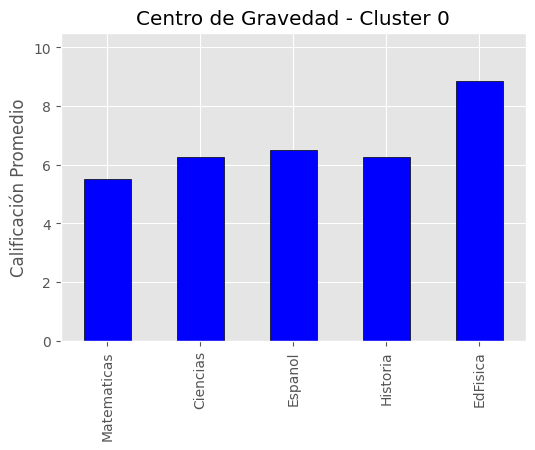

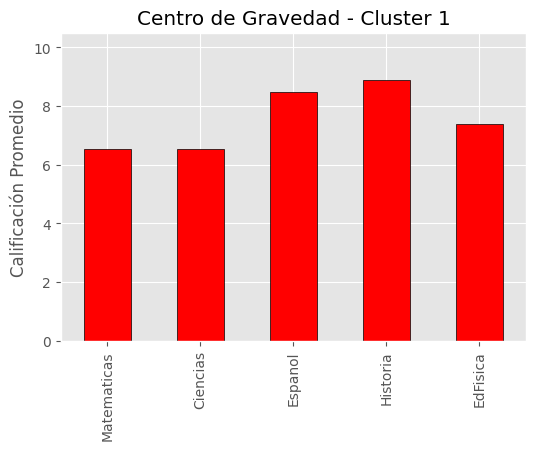

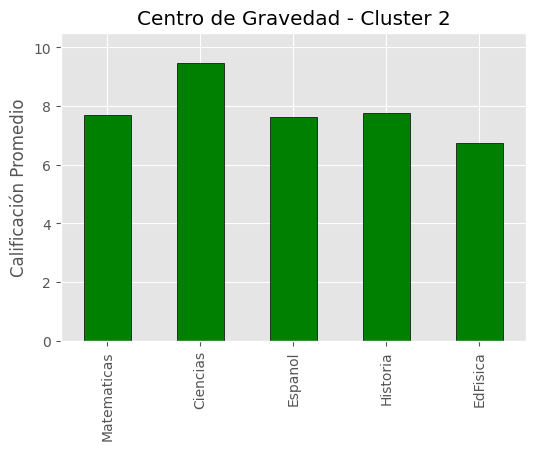

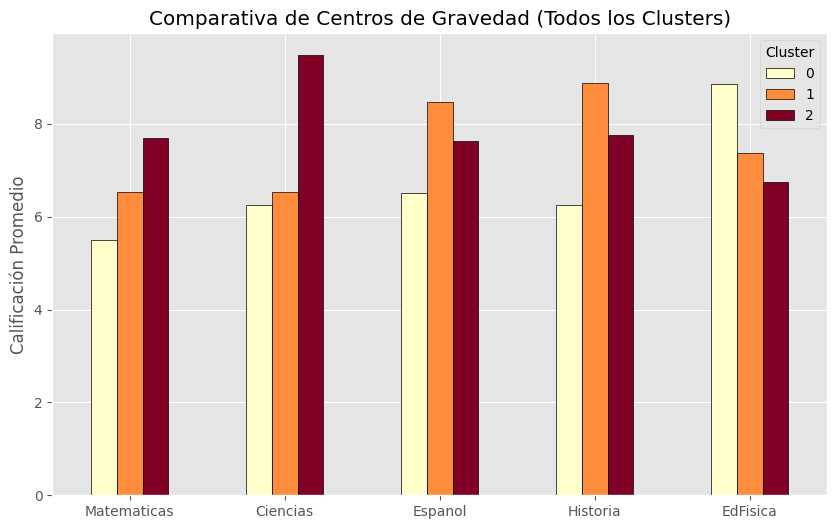

In [5]:
# Obtenemos los centros de gravedad (centroides) agrupando por el cluster
centroides = df.groupby('Cluster_KMeans').mean()

# NOTA: En Python los índices empiezan en 0, por lo que los clusters serán 0, 1 y 2 
# (equivalentes a 1, 2 y 3 en R).

# 5.1 Gráfico individual para el Cluster 0 (Color Azul)
plt.figure(figsize=(6, 4))
centroides.iloc[0].plot(kind='bar', color='blue', edgecolor='black')
plt.title('Centro de Gravedad - Cluster 0')
plt.ylim(0, 10.5)
plt.ylabel('Calificación Promedio')
plt.show()

# 5.2 Gráfico individual para el Cluster 1 (Color Rojo)
plt.figure(figsize=(6, 4))
centroides.iloc[1].plot(kind='bar', color='red', edgecolor='black')
plt.title('Centro de Gravedad - Cluster 1')
plt.ylim(0, 10.5)
plt.ylabel('Calificación Promedio')
plt.show()

# 5.3 Gráfico individual para el Cluster 2 (Color Verde)
plt.figure(figsize=(6, 4))
centroides.iloc[2].plot(kind='bar', color='green', edgecolor='black')
plt.title('Centro de Gravedad - Cluster 2')
plt.ylim(0, 10.5)
plt.ylabel('Calificación Promedio')
plt.show()

# 5.4 Gráfica de los tres clusters completos juntos (Equivalente a "beside = TRUE" con colores cálidos)
# Usamos .T (Transpuesta) para que las materias queden en el eje X y los clusters sean las barras
centroides.T.plot(kind='bar', figsize=(10, 6), colormap='YlOrRd', edgecolor='black')
plt.title('Comparativa de Centros de Gravedad (Todos los Clusters)')
plt.ylabel('Calificación Promedio')
plt.xticks(rotation=0)
plt.legend(title='Cluster')
plt.show()

### Paso 6. Interpretar los Clusters.

A partir del análisis de los centros de gravedad visualizados en los gráficos de barras, podemos definir los perfiles académicos descubiertos por el algoritmo **K-Means**:

* **Cluster 1 (Humanidades y Letras):** Agrupa a estudiantes (como Andrés, Carlos, Lucía y María) que se caracterizan por ser destacados en las áreas de Español e Historia.
* **Cluster 2 (Ciencias Exactas):** Sus integrantes (como Ana, Inés, José y Pedro) se destacan fuertemente por sus altas calificaciones en las áreas de Matemáticas y Ciencias.
* **Cluster 3 (Deportistas):** Este grupo (como Luis y Sonia) se ve fuertemente impactado de manera positiva por las notas de Educación Física, es decir, son buenos deportistas y su rendimiento principal se concentra en actividades kinestésicas.

**Conclusión General:** El algoritmo de aprendizaje no supervisado K-Means fue capaz de encontrar los tres perfiles naturales de los estudiantes basándose puramente en la similitud matemática de sus calificaciones, sin necesidad de etiquetas previas.

## Conclusiones

En esta práctica, implementamos con éxito el algoritmo de **K-Means**, una de las técnicas más utilizadas en el aprendizaje no supervisado (Machine Learning). A diferencia de los modelos de clasificación supervisada que hemos trabajado anteriormente, aquí el algoritmo fue capaz de descubrir la estructura oculta de los datos sin conocer previamente ninguna etiqueta o categoría de los estudiantes.

Durante el desarrollo de la práctica logramos:
1. **Validar el número de clusters ($k=3$):** Aunque la práctica sugería 3 grupos, comprobamos matemáticamente esta elección utilizando el Método del Codo (analizando la inercia).
2. **Reducción de Dimensionalidad (PCA):** Transformamos un problema de 5 dimensiones (5 materias) a un espacio de 2 componentes principales para lograr una visualización gráfica clara y comprensible de la separación de los grupos.
3. **Interpretación de Centroides:** Tradujimos los resultados matemáticos en perfiles reales. Identificamos que los datos se agrupan de manera natural en estudiantes con afinidad a las Ciencias Exactas, a las Humanidades/Letras, y al rendimiento Físico/Deportivo.

Esta práctica demuestra el gran valor del clustering para la segmentación de datos, una herramienta invaluable no solo en la educación, sino en marketing, biología y análisis de comportamiento.